<a href="https://colab.research.google.com/github/pinchunc/NMA_DL_SentimentAnalysis/blob/main/notebooks/roberta_binary_basemodel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import torch

from datasets import Dataset
from transformers import (
    RobertaTokenizer,
    RobertaForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings('ignore')
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch device: {device}")
print(f"CUDA available: {torch.cuda.is_available()}")

2025-07-21 17:14:49.461810: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1753118089.674120      36 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1753118089.733862      36 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


PyTorch device: cuda
CUDA available: True


In [ ]:
import random

def set_seed(seed=2025):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(2025)

In [ ]:
# Load and prepare data
url = 'https://raw.githubusercontent.com/pinchunc/NMA_DL_SentimentAnalysis/main/data/hippoCorpusV2.csv'
df = pd.read_csv(url)

# Convert to binary
def map_stress_to_binary(stress_level):
    return 0 if stress_level == 1 else 1

# Only include recalled stories
def filter_recalled(df):
    return df[df['memType'] == "recalled"]

df = filter_recalled(df)
df['labels'] = df['stressful'].apply(map_stress_to_binary).astype(int)
df = df[['story', 'labels']]

print(f"Dataset: {df.shape}, Labels: 0={sum(df['labels']==0)}, 1={sum(df['labels']==1)}")

Dataset: (2779, 2), Labels: 0=1143, 1=1636


In [ ]:
# First split: Separate test set (10%)
train_val_texts, test_texts, train_val_labels, test_labels = train_test_split(
    df['story'].tolist(),
    df['labels'].tolist(),
    test_size=0.1,  # 10% for testing
    random_state=2025,
    stratify=df['labels']
)

# Second split: Split remaining 90% into train (80%) and validation (10%)
train_texts, val_texts, train_labels, val_labels = train_test_split(
    train_val_texts,
    train_val_labels,
    test_size=0.111,  # 10% of total = 0.1/0.9 ≈ 0.111 of remaining
    random_state=2025,
    stratify=train_val_labels
)

# Create datasets
train_dataset = Dataset.from_dict({'text': train_texts, 'labels': train_labels})
val_dataset = Dataset.from_dict({'text': val_texts, 'labels': val_labels})
test_dataset = Dataset.from_dict({'text': test_texts, 'labels': test_labels})

# Print split information
total_samples = len(df)
print(f"Total samples: {total_samples}")
print(f"Training: {len(train_texts)} ({len(train_texts)/total_samples*100:.1f}%)")
print(f"Validation: {len(val_texts)} ({len(val_texts)/total_samples*100:.1f}%)")
print(f"Testing: {len(test_texts)} ({len(test_texts)/total_samples*100:.1f}%)")

Total samples: 2779
Training: 2223 (80.0%)
Validation: 278 (10.0%)
Testing: 278 (10.0%)


In [ ]:
# Initialize model and tokenizer
tokenizer = RobertaTokenizer.from_pretrained("distilroberta-base")
model = RobertaForSequenceClassification.from_pretrained("distilroberta-base", num_labels=2)
model = model.to(device)

# Tokenization
def tokenize_function(examples):
    return tokenizer(examples['text'], truncation=True, padding=False, max_length=512)  # Shorter for CPU

train_dataset = train_dataset.map(tokenize_function, batched=True)
val_dataset = val_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/480 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/331M [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at distilroberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Map:   0%|          | 0/2223 [00:00<?, ? examples/s]

Map:   0%|          | 0/278 [00:00<?, ? examples/s]

Map:   0%|          | 0/278 [00:00<?, ? examples/s]

In [ ]:
# Enhanced metrics function
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=-1)

    # Calculate multiple metrics
    accuracy = accuracy_score(labels, predictions)

    from sklearn.metrics import precision_recall_fscore_support, confusion_matrix
    precision, recall, f1, _ = precision_recall_fscore_support(labels, predictions, average='weighted')

    return {
        "accuracy": accuracy,
        "f1": f1,
        "precision": precision,
        "recall": recall
    }

In [ ]:
# Data collator
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# Training arguments
training_args = TrainingArguments(
    output_dir="./roberta-stress-model",
    num_train_epochs=1,  # Increased for better training
    per_device_train_batch_size=64,  # Larger batch for better training i.e. 64 # when increase batch size, should also increase lr
    per_device_eval_batch_size=64,
    learning_rate=4e-5,
    warmup_steps=100,
    weight_decay=0.01,
    logging_steps=10, # try smaller

    # VALIDATION DURING TRAINING
    eval_strategy="steps",
    eval_steps=10,  # Evaluate after each epoch
    save_strategy="steps",  # Save best model
    load_best_model_at_end=True,  # Load best model based on validation
    metric_for_best_model="eval_accuracy",  # Use accuracy to pick best model
    greater_is_better=True,  # Higher accuracy is better

    report_to="none",
    dataloader_pin_memory=False,
)


# Create trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

In [ ]:
# Training phase
print("Starting training with validation...")
trainer.train()

Starting training with validation...


Step,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
10,0.676600,0.677128,0.589928,0.437775,0.348015,0.589928
20,0.683000,0.673494,0.589928,0.437775,0.348015,0.589928
30,0.681100,0.662502,0.589928,0.437775,0.348015,0.589928
40,0.651800,0.594249,0.669065,0.670537,0.673111,0.669065
50,0.618100,0.576056,0.694245,0.694819,0.695555,0.694245
60,0.619300,0.580087,0.683453,0.686028,0.700522,0.683453
70,0.593200,0.565218,0.715827,0.715221,0.714782,0.715827
80,0.602700,0.559096,0.715827,0.716013,0.716218,0.715827
90,0.563500,0.548848,0.744604,0.744771,0.744958,0.744604
100,0.530600,0.558899,0.708633,0.710942,0.728664,0.708633


TrainOutput(global_step=144, training_loss=0.5768713139825397, metrics={'train_runtime': 258.0502, 'train_samples_per_second': 68.917, 'train_steps_per_second': 0.558, 'total_flos': 1177900108849152.0, 'train_loss': 0.5768713139825397, 'epoch': 8.0})

In [ ]:
trainer.save_model("./roberta-stressbinary-classifier")
print("Model saved!")

In [ ]:
import matplotlib.pyplot as plt

# Get training history
logs = trainer.state.log_history
logs

[{'loss': 0.6766,
  'grad_norm': 0.6150785684585571,
  'learning_rate': 3.6000000000000003e-06,
  'epoch': 0.5555555555555556,
  'step': 10},
 {'eval_loss': 0.6771279573440552,
  'eval_accuracy': 0.5899280575539568,
  'eval_f1': 0.4377746671441128,
  'eval_precision': 0.3480151130893846,
  'eval_recall': 0.5899280575539568,
  'eval_runtime': 1.1608,
  'eval_samples_per_second': 239.497,
  'eval_steps_per_second': 2.585,
  'epoch': 0.5555555555555556,
  'step': 10},
 {'loss': 0.683,
  'grad_norm': 0.7163983583450317,
  'learning_rate': 7.600000000000001e-06,
  'epoch': 1.1111111111111112,
  'step': 20},
 {'eval_loss': 0.673494279384613,
  'eval_accuracy': 0.5899280575539568,
  'eval_f1': 0.4377746671441128,
  'eval_precision': 0.3480151130893846,
  'eval_recall': 0.5899280575539568,
  'eval_runtime': 1.2087,
  'eval_samples_per_second': 229.99,
  'eval_steps_per_second': 2.482,
  'epoch': 1.1111111111111112,
  'step': 20},
 {'loss': 0.6811,
  'grad_norm': 0.8953086137771606,
  'learning

In [ ]:
# Extract training and validation data
train_loss = []
train_accuracy = []
val_loss = []
val_accuracy = []
epochs = []

for log in logs:
    if 'loss' in log:  # End of epoch training loss
        train_loss.append(log['loss'])
        # train_accuracy.append(log['train_accuracy'])
    if 'eval_loss' in log:   # Validation loss
        val_loss.append(log['eval_loss'])
        val_accuracy.append(log['eval_accuracy'])
        epochs.append(log['epoch'])

In [ ]:
val_loss

[0.6771279573440552,
 0.673494279384613,
 0.6625022888183594,
 0.5942485928535461,
 0.5760564804077148,
 0.5800865888595581,
 0.5652180314064026,
 0.559095561504364,
 0.5488484501838684,
 0.5588985681533813,
 0.5741394758224487,
 0.5595462918281555,
 0.6063123345375061,
 0.592615008354187]

In [ ]:
train_loss # every 50 steps

[0.6766,
 0.683,
 0.6811,
 0.6518,
 0.6181,
 0.6193,
 0.5932,
 0.6027,
 0.5635,
 0.5306,
 0.5418,
 0.5123,
 0.461,
 0.4223]

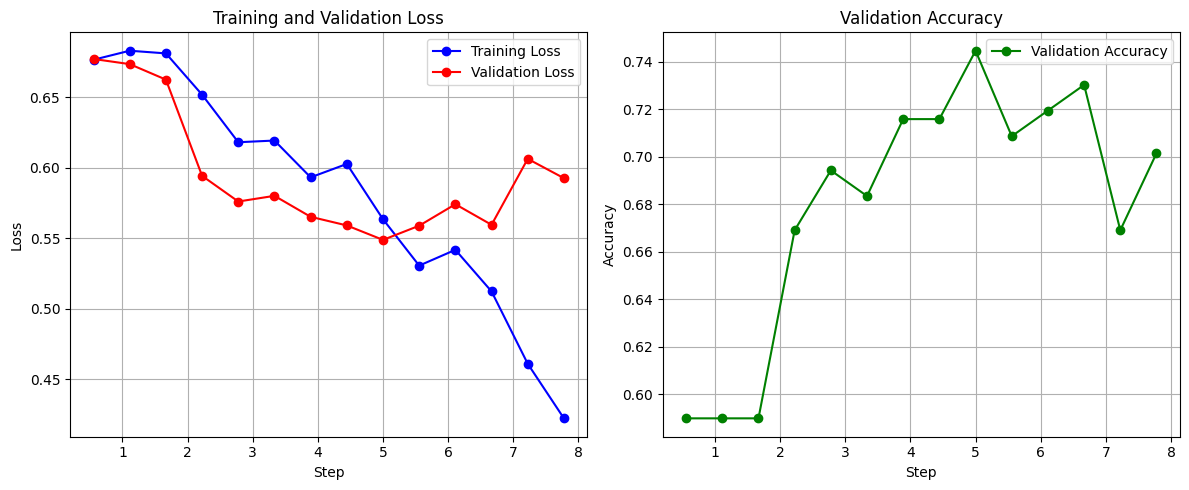

In [ ]:
# Create simple plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Loss
if len(train_loss) > 0 and len(val_loss) > 0:
    ax1.plot(epochs, train_loss, 'b-o', label='Training Loss')
    ax1.plot(epochs, val_loss, 'r-o', label='Validation Loss')
    ax1.set_xlabel('Step')
    ax1.set_ylabel('Loss')
    ax1.set_title('Training and Validation Loss')
    ax1.legend()
    ax1.grid(True)

# Plot 2: Validation Accuracy
if len(val_accuracy) > 0:
    ax2.plot(epochs, val_accuracy, 'g-o', label='Validation Accuracy')
    ax2.set_xlabel('Step')
    ax2.set_ylabel('Accuracy')
    ax2.set_title('Validation Accuracy')
    ax2.legend()
    ax2.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# Validation set evaluation
val_results = trainer.evaluate(eval_dataset=val_dataset)
print(val_results)

{'eval_loss': 0.6025343537330627, 'eval_accuracy': 0.6870503597122302, 'eval_f1': 0.6891824735620217, 'eval_precision': 0.7132179694047166, 'eval_recall': 0.6870503597122302, 'eval_runtime': 1.4396, 'eval_samples_per_second': 193.112, 'eval_steps_per_second': 2.084, 'epoch': 8.0}


In [ ]:
# Test set evaluation
test_results = trainer.evaluate(eval_dataset=test_dataset)
print(test_results)

{'eval_loss': 0.789193332195282, 'eval_accuracy': 0.6115107913669064, 'eval_f1': 0.6146267985611511, 'eval_precision': 0.6301192682970442, 'eval_recall': 0.6115107913669064, 'eval_runtime': 1.4519, 'eval_samples_per_second': 191.478, 'eval_steps_per_second': 2.066, 'epoch': 8.0}


In [ ]:
def predict_text(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=256)
    inputs = {k: v.to(device) for k, v in inputs.items()}

    model.eval()
    with torch.no_grad():
        outputs = model(**inputs)
        prediction = torch.argmax(outputs.logits, dim=-1).item()

    return prediction

In [ ]:
# Calculate accuracy manually on entire test set
correct_predictions = 0
total_predictions = len(test_texts)

print(f"Processing {total_predictions} test examples...")

for i, (text, actual_label) in enumerate(zip(test_texts, test_labels)):
    if i % 100 == 0:  # Progress indicator
        print(f"  Processed {i}/{total_predictions} examples...")

    predicted_label = predict_text(text)

    if predicted_label == actual_label:
        correct_predictions += 1

# Final results
manual_accuracy = correct_predictions / total_predictions

print(f"Correct predictions: {correct_predictions}")
print(f"Total predictions: {total_predictions}")
print(f"Accuracy: {manual_accuracy:.4f} ({manual_accuracy:.1%})")

In [ ]:
# Show breakdown by class
stressed_correct = 0
stressed_total = 0
not_stressed_correct = 0
not_stressed_total = 0

for i, (text, actual_label) in enumerate(zip(test_texts, test_labels)):
    predicted_label = predict_text(text)

    if actual_label == 1:  # Stressed
        stressed_total += 1
        if predicted_label == actual_label:
            stressed_correct += 1
    else:  # Not stressed
        not_stressed_total += 1
        if predicted_label == actual_label:
            not_stressed_correct += 1

print(f"\n📊 ACCURACY BY CLASS:")
print(f"Not Stressed: {not_stressed_correct}/{not_stressed_total} = {not_stressed_correct/not_stressed_total:.1%}")
print(f"Stressed: {stressed_correct}/{stressed_total} = {stressed_correct/stressed_total:.1%}")

In [ ]:
# Show a few examples for illustration
print(f"\n📝 SAMPLE PREDICTIONS (first 5 examples):")
import random
random.seed(42)
sample_indices = random.sample(range(len(test_texts)), 5)

for i, idx in enumerate(sample_indices, 1):
    text = test_texts[idx]
    actual = test_labels[idx]
    pred = predict_text(text)

    actual_label = "Stressed" if actual == 1 else "Not Stressed"
    pred_label = "Stressed" if pred == 1 else "Not Stressed"
    status = "✅" if pred == actual else "❌"

    display_text = text[:60] + "..." if len(text) > 60 else text

    print(f"{i}. \"{display_text}\"")
    print(f"   Actual: {actual_label} | Predicted: {pred_label} {status}")
    print()